In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import s3fs
import rioxarray as rio
import xarray as xr
import xarray_regrid
import os

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10 ) !important;
    }
</style>
"""))

In [2]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

In [3]:
fs.get('gaia/cjense/data/velocity/basin_velocity_ZI.zarr', '/tmp/basin_velocity_ZI.zarr')

In [4]:
meltwater = xr.open_dataset('~/Downloads/meltwater2000_2025_daily.nc')
# fs.get('gaia/cjense/data/velocity/basin_velocity_ZI.zarr', '/tmp/basin_velocity_ZI.zarr')
# fs.get('gaia/cjense/data/velocity/ZI_79N_velseries_monthly.nc', '/tmp/ZI_79N_velseries_monthly.nc')
# velocity = xr.open_dataset('~/Downloads/ZI_79N_velseries_combined.zarr', engine='zarr', consolidated=False)
# velocity.to_netcdf('~/Downloads/ZI_79N_velseries_combined.nc')
velocity = xr.open_dataset('~/Downloads/ZI_79N_velseries_combined.nc')

In [5]:
meltwater = meltwater.RU.sel(SECTOR=1).assign_coords(
    x=meltwater.x * 1000,
    y=meltwater.y * 1000,
)
meltwater["x"].attrs["units"] = "m"
meltwater["y"].attrs["units"] = "m"

In [6]:
# velocity.chunk({'time': 50, 'x': 100, 'y': 100})
# meltwater.chunk({'TIME': 100, 'x': 8, 'y': 8, 'SECTOR': 1})

velocity = velocity.rio.write_crs("EPSG:3413")
meltwater = meltwater.rio.write_crs("EPSG:3413")

meltwater = meltwater.chunk({"TIME": 100, "x": -1, "y": -1})

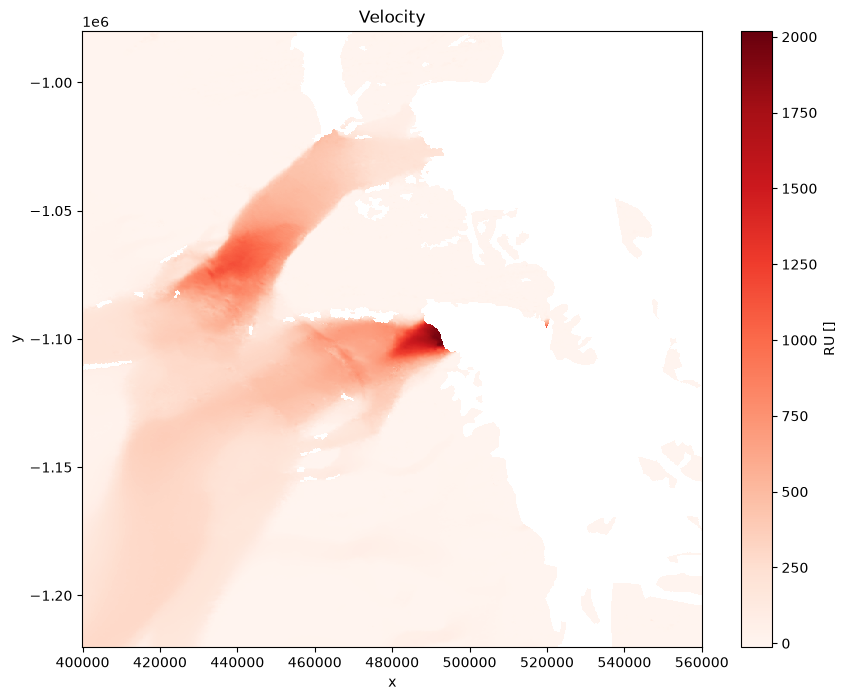

In [7]:
v = velocity.VelocityMap.sel(time='2025-11-27T12:00:00.000000000').mean(dim='band')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    v.x,
    v.y,
    v,
    cmap="Reds",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{v.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Velocity")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

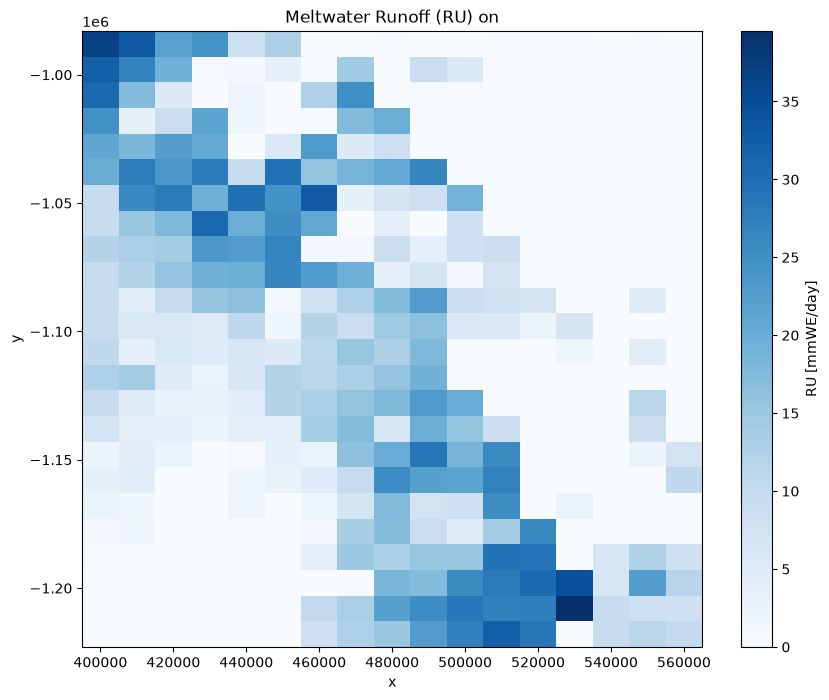

In [8]:
ru_day = meltwater.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)

# im1 = ax.pcolormesh(
#     v.x,
#     v.y,
#     v,
#     cmap="Reds",
#     shading="auto",
# )
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")
# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


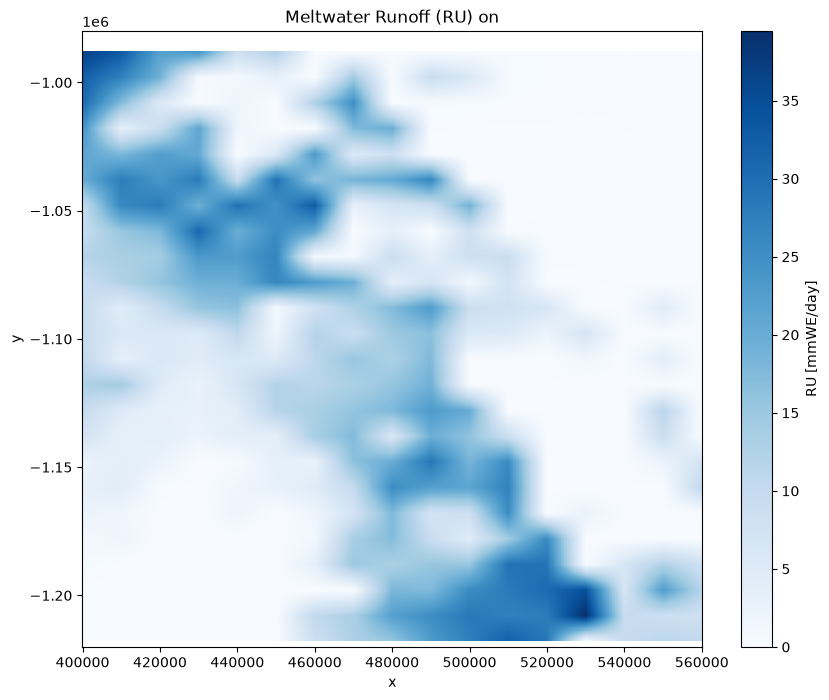

In [9]:
meltwater_linear = meltwater.regrid.linear(velocity, time_dim="TIME")

ru_day = meltwater_linear.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
# im1 = ax.pcolormesh(
#     v.x,
#     v.y,
#     v,
#     cmap="Reds",
#     shading="auto",
# )
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


In [10]:
basins = gpd.read_file("/Users/cjense/Desktop/phd/data/Greenland Basins/Greenland_Basins_PS_v1.4.2.shp")
zibasin = basins.loc[basins['NAME']=='ZACHARIAE_ISSTROM']
basin79n = basins.loc[basins['NAME']=='NIOGHALVFJERDSFJORDEN']
basins

,SUBREGION1,NAME,GL_TYPE,geometry
0,NW,UMIAMMAKKU_ISBRAE,TW,"POLYGON ((-250013.97 -1962482.806, -250392.427..."
1,CE,GEIKIE_UNNAMED_VESTFORD_S,TW,"POLYGON ((669064.856 -2093802.344, 668921.855 ..."
2,CW,RINK_ISBRAE,TW,"POLYGON ((245236.056 -1890271.273, 242838.452 ..."
3,CW,KANGERLUSSUUP_SERMERSUA,TW,"POLYGON ((245014.582 -1891216.649, 240674.78 -..."
4,CW,CW_NONAME3,LT,"POLYGON ((-196828.245 -2054377.448, -197638.91..."
...,...,...,...,...
255,CE,ICE_CAPS_CE,TW,"MULTIPOLYGON (((480453.985 -2471075.871, 48051..."
256,SE,GLACIERDEFRANCE,TW,"POLYGON ((417931.72 -2529065.683, 418087.619 -..."
257,SE,KNUD-RASMUSSEN,TW,"POLYGON ((408724.018 -2578806.113, 409354.054 ..."
258,SE,NIGERTULUUP_KATTILERTARPIA,TW,"POLYGON ((429219.393 -2549303.299, 429590.715 ..."


In [11]:
zi_geom = zibasin.to_crs(meltwater.rio.crs).geometry.union_all()

zi_clipped = meltwater_linear.rio.clip(
    [zi_geom],
    crs=meltwater.rio.crs,
    drop=True,
)

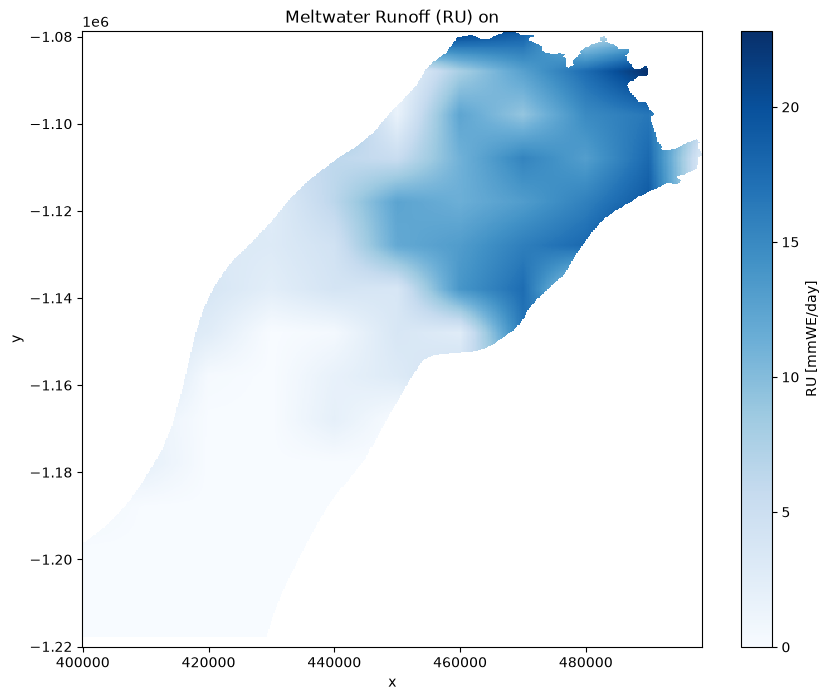

In [12]:
meltwater_linear = meltwater.regrid.linear(velocity, time_dim="TIME")

ru_day = zi_clipped.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
# im1 = ax.pcolormesh(
    # v.x,
    # v.y,
    # v,
    # cmap="Reds",
    # shading="auto",
# )
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


In [14]:
zi_clipped

<xarray.DataArray 'RU' (TIME: 9490, y: 707, x: 493)> Size: 13GB
dask.array<getitem, shape=(9490, 707, 493), dtype=float32, chunksize=(100, 707, 493), chunktype=numpy.ndarray>
Coordinates:
  * TIME         (TIME) datetime64[ns] 76kB 1999-12-30T12:00:00 ... 2025-12-2...
  * y            (y) float64 6kB -1.079e+06 -1.079e+06 ... -1.22e+06 -1.22e+06
  * x            (x) float64 4kB 4e+05 4.002e+05 ... 4.982e+05 4.984e+05
    SECTOR       float32 4B 1.0
    crs          int64 8B 0
    name         <U4 16B 'None'
    spatial_ref  int64 8B 0
Attributes:
    long_name:  Run-off of meltwater and rain water
    units:      mmWE/day

In [16]:
zi_clipped = zi_clipped.chunk({"TIME": 100, "x": -1, "y": -1})

zi_clipped.to_dataset(name="RU").to_zarr(
    "s3://gaia/cjensen/data/mar/meltwater_regridded_daily_ZI.zarr",
    storage_options=storage_options,
    mode="w",
    consolidated=False,
)

KeyboardInterrupt: 

## Ignore below

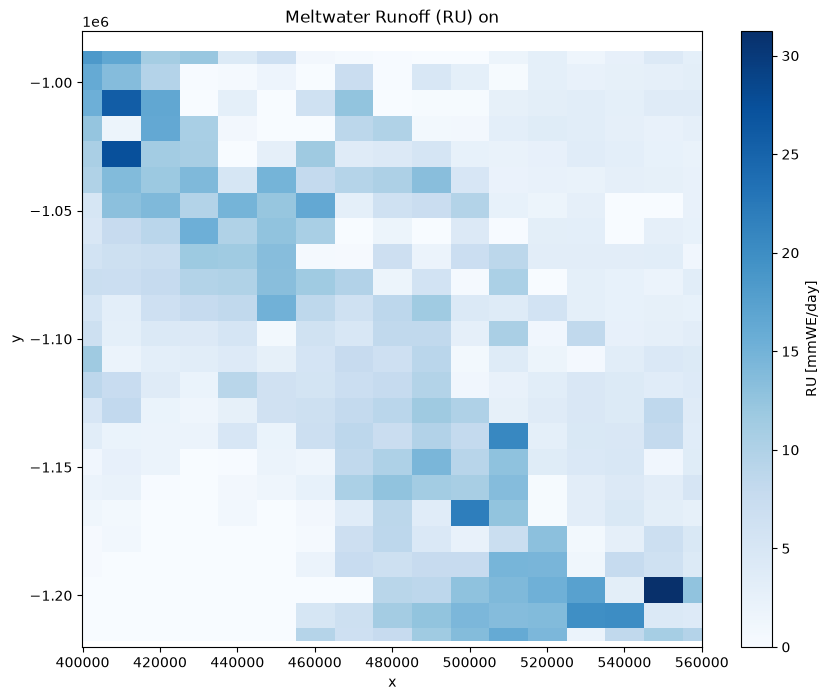

In [29]:
meltwater_nearest = meltwater.regrid.nearest(velocity, time_dim="TIME")

ru_day = meltwater_nearest.RU.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


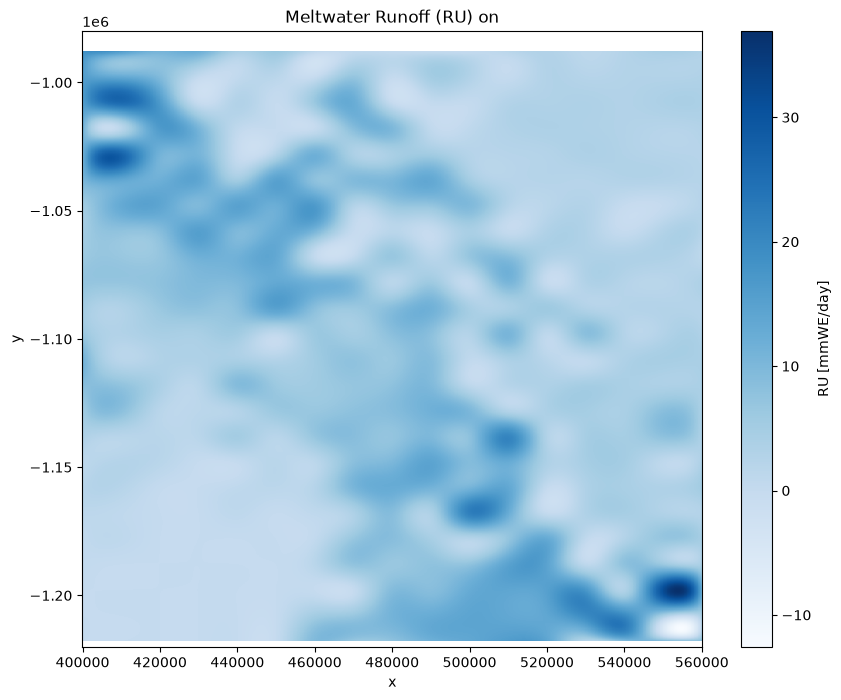

In [30]:
meltwater_cubic = meltwater.regrid.cubic(velocity, time_dim="TIME")

ru_day = meltwater_cubic.RU.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


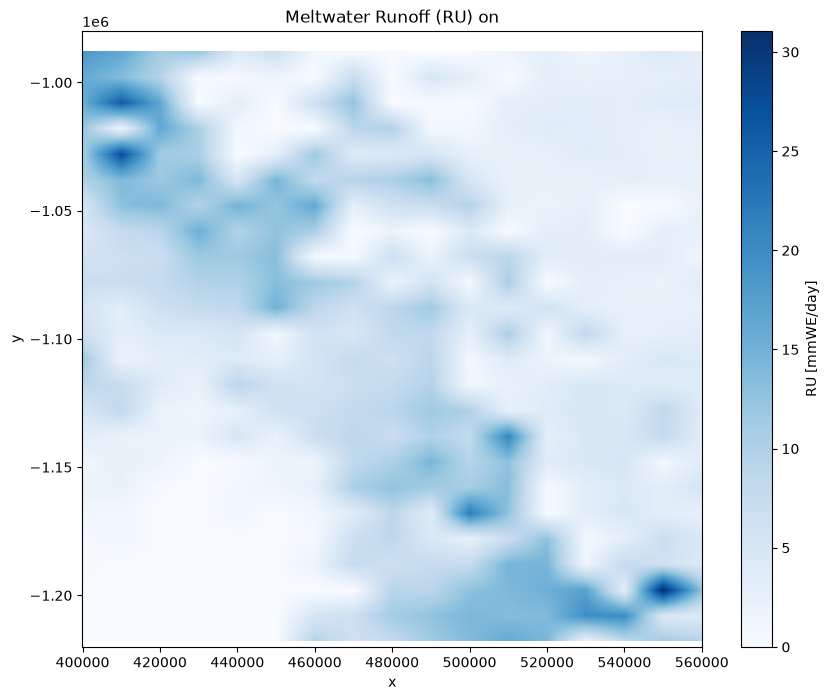

In [31]:
interp_linear = meltwater.interp_like(velocity, method='linear')

ru_day = interp_linear.RU.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


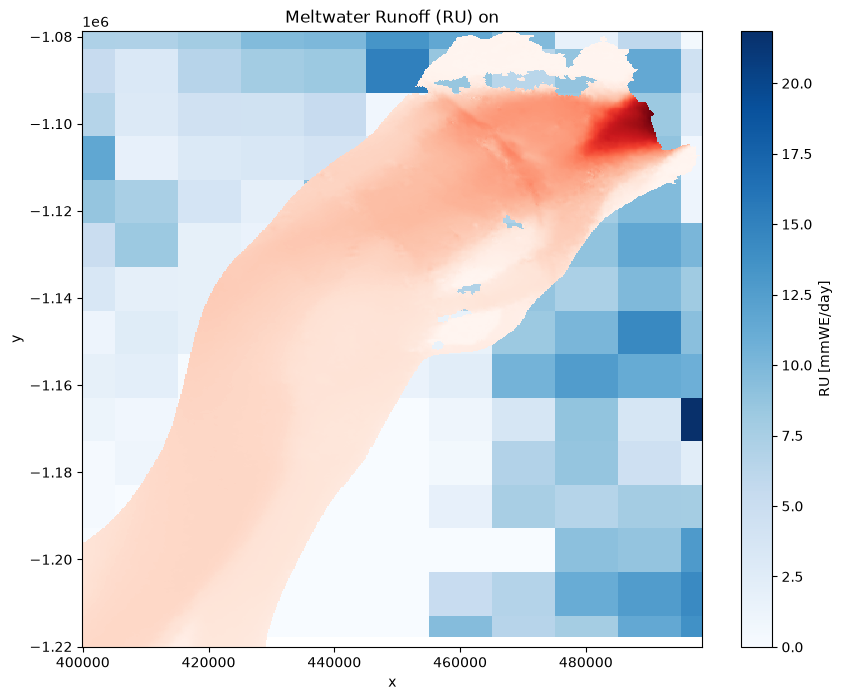

In [13]:
interp_nearest = meltwater.interp_like(velocity, method='nearest')

ru_day = interp_nearest.RU.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
im1 = ax.pcolormesh(
    v.x,
    v.y,
    v,
    cmap="Reds",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


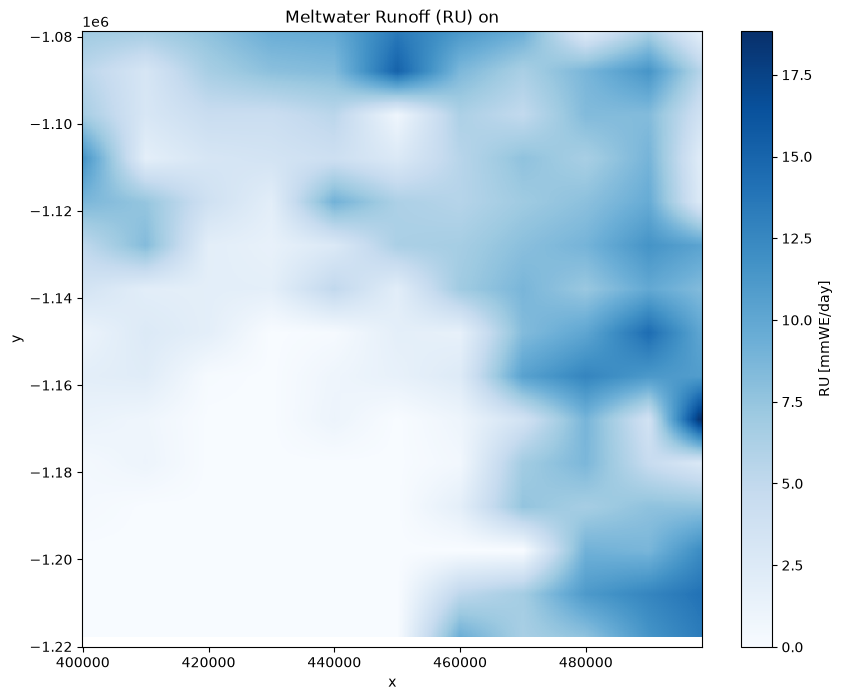

In [14]:
interp_slinear = meltwater.interp_like(velocity, method='slinear')

ru_day = interp_slinear.RU.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


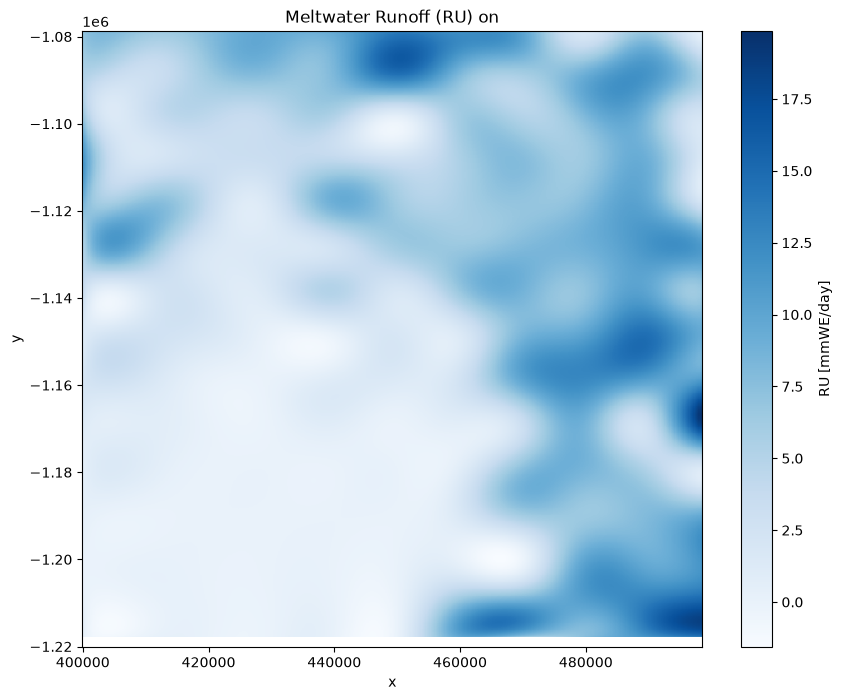

In [16]:
interp_quintic = meltwater.interp_like(velocity, method='quintic')

ru_day = interp_quintic.RU.sel(TIME='2000-07-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


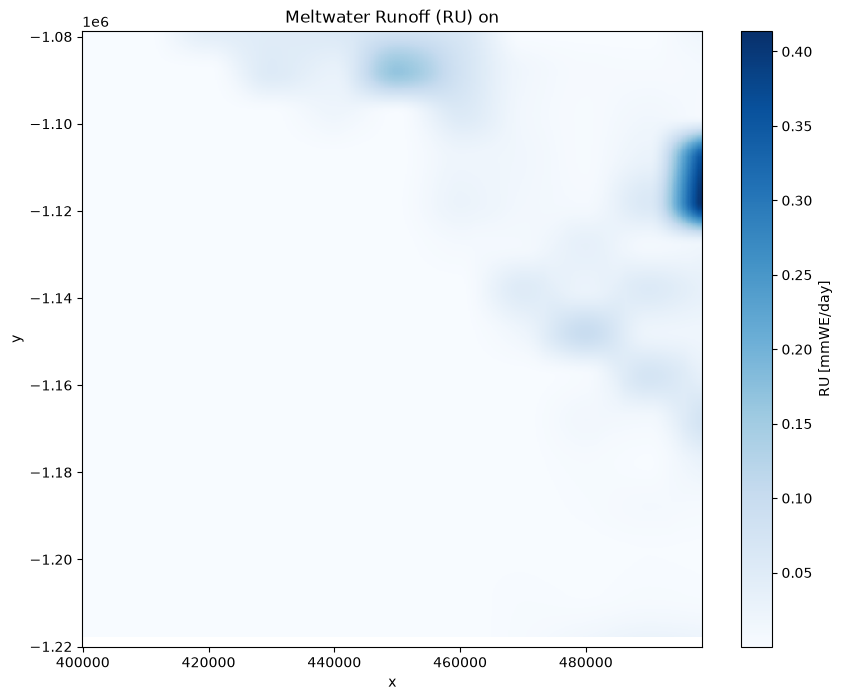

In [19]:
interp_quintic = meltwater.interp_like(velocity, method='pchip')

ru_day = interp_quintic.RU.sel(TIME='2000-01-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


In [ ]:
meltwater_conservative = meltwater.regrid.conservative(velocity, time_dim="TIME")
# Explicitly transpose with missing_dims to handle the dimension mismatch
meltwater_conservative = meltwater_conservative.transpose("TIME", "y", "x", missing_dims="ignore")

ru_day = meltwater_conservative.RU.sel(TIME='2000-01-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()


/Users/cjense/Desktop/phd/negis-seasonality/.pixi/envs/default/lib/python3.14/site-packages/dask/array/einsumfuncs.py:273: PerformanceWarning: Increasing number of chunks by factor of 870
  result = blockwise(
/Users/cjense/Desktop/phd/negis-seasonality/.pixi/envs/default/lib/python3.14/site-packages/dask/array/einsumfuncs.py:273: PerformanceWarning: Increasing number of chunks by factor of 870
  result = blockwise(
/Users/cjense/Desktop/phd/negis-seasonality/.pixi/envs/default/lib/python3.14/site-packages/dask/array/einsumfuncs.py:273: PerformanceWarning: Increasing number of chunks by factor of 870
  result = blockwise(
/Users/cjense/Desktop/phd/negis-seasonality/.pixi/envs/default/lib/python3.14/site-packages/dask/array/einsumfuncs.py:273: PerformanceWarning: Increasing number of chunks by factor of 870
  result = blockwise(
/Users/cjense/Desktop/phd/negis-seasonality/.pixi/envs/default/lib/python3.14/site-packages/dask/array/einsumfuncs.py:273: PerformanceWarning: Increasing number

ValueError: ('TIME',) must be a permuted list of ('TIME', 'y', 'x'), unless `...` is included

In [6]:
meltwater_regridded

<xarray.Dataset> Size: 529GB
Dimensions:      (TIME: 9490, y: 707, x: 493, SECTOR: 2, SECTOR1_1: 1)
Coordinates:
  * TIME         (TIME) datetime64[ns] 76kB 1999-12-30T12:00:00 ... 2025-12-2...
  * y            (y) float64 6kB -1.079e+06 -1.079e+06 ... -1.22e+06 -1.22e+06
  * x            (x) float64 4kB 4e+05 4.002e+05 ... 4.982e+05 4.984e+05
  * SECTOR       (SECTOR) float32 8B 1.0 2.0
  * SECTOR1_1    (SECTOR1_1) float32 4B 1.0
    crs          int64 8B 0
    spatial_ref  int64 8B 0
    name         <U4 16B 'None'
Data variables: (12/36)
    LON          (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    LAT          (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    SH           (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    SRF          (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    SOL          (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    MSK          (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    ...           ...
    LHF          (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    SHF          (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    AL1          (TIME, SECTOR, y, x) float32 26GB dask.array<chunksize=(100, 1, 707, 493), meta=np.ndarray>
    AL2          (TIME, SECTOR, y, x) float32 26GB dask.array<chunksize=(100, 1, 707, 493), meta=np.ndarray>
    SP           (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
    SLP          (TIME, y, x) float32 13GB dask.array<chunksize=(100, 707, 493), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    institute:    University of Liege (Belgium)
    contact:      xavier.fettweis@uliege.be
    model:        regional climate model MAR (v3.14.3)
    date:         Tue Nov 18 08:49:52 CET 2025
    units:        m

In [11]:
def print_raster(raster):
    print(
        f"shape: {raster.rio.shape}\n"
        f"resolution: {raster.rio.resolution()}\n"
        f"bounds: {raster.rio.bounds()}\n"
        f"sum: {raster.sum().item()}\n"
        f"CRS: {raster.rio.crs}\n"
    )
print_raster(velocity.VelocityMap)
print_raster(meltwater.RU)

shape: (707, 493)
resolution: (200.0, -200.0)
bounds: (399900.0, -1220100.0, 498500.0, -1078700.0)
sum: 50525691904.0
CRS: EPSG:3413

shape: (24, 17)
resolution: (10.0, 10.0)
bounds: (395.0, -1222.927734375, 565.0, -982.927734375)
sum: 7652000.0
CRS: EPSG:3413



In [12]:
regridded_runoff = meltwater.RU.regrid.linear(velocity.VelocityMap)

: 

In [6]:
velocity_res = 200  # meters

# Regrid using xarray-regrid with Dask
# output_zarr = "s3://gaia/cjense/data/mar/meltwater_RU_regridded_ZI.zarr"

print("Regridding meltwater.RU to match velocity.VelocityMap resolution...")
print(f"Original meltwater.RU shape: {meltwater.RU.shape}")
print(f"Target velocity shape: {velocity.VelocityMap.isel(time=0).shape}")

# Get target coordinates from velocity (using first time step)
target_x = velocity.VelocityMap.x
target_y = velocity.VelocityMap.y

# Regrid RU using xarray-regrid (works with Dask)
regridded_ru = xarray_regrid.regrid_2d(
    meltwater.RU,
    target_x,
    target_y,
    x_dim='x',
    y_dim='y',
    method='bilinear'
)

print(f"Regridded shape: {regridded_ru.shape}")

# Write to zarr using chunks
print("\nWriting to zarr...")
regridded_ru.to_dataset(name="RU").to_zarr(
    output_zarr,
    mode="w",
    consolidated=False,
    encoding={
        "RU": {
            "chunks": (50, 1, velocity.VelocityMap.rio.shape[0], velocity.VelocityMap.rio.shape[1])
        }
    }
)

print(f"Regridded RU data written to: {output_zarr}")

Regridding meltwater.RU to match velocity.VelocityMap resolution...
Original meltwater.RU shape: (9490, 2, 24, 17)
Target velocity shape: (3, 707, 493)


AttributeError: module 'xarray_regrid' has no attribute 'regrid_2d'

In [30]:
melt = xr.open_dataset("s3://gaia/cjense/data/mar/meltwater_RU_regridded_ZI.zarr",
                     storage_options=storage_options,
                     zarr_format=3,
                     consolidated=False,
                     mode="r",
                     engine="zarr"
)

In [8]:
ru_day = meltwater_regridded.RU.transpose("TIME", "SECTOR", "y", "x").sel(TIME='2000-01-10T12:00:00.000000000', method="nearest").mean(dim="SECTOR")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(
    ru_day.x,
    ru_day.y,
    ru_day,
    cmap="Blues",
    shading="auto",
)
fig.colorbar(im, ax=ax, label=f"RU [{ru_day.attrs.get('units', '')}]")

# ax.scatter(xpts, ypts, color="black", s=30, zorder=3)

ax.set_title(f"Meltwater Runoff (RU) on")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()

NameError: name 'meltwater_regridded' is not defined